In [ ]:
import pathlib

In [ ]:
import marimo as mo
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-06-18T18:29:48.630286+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1059-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

teeplot   : 1.4.2
marimo    : 0.23.2
seaborn   : 0.13.2
numpy     : 2.1.2
matplotlib: 3.10.7
pandas    : 2.2.3
requests  : 2.34.2

```

## Data

Load the per-replicate **strain** and **Hamming-weight** prevalence
time series produced by the 3-site mutation-rate sweep slurm job
(`slurm/2026-06-17/2026-06-17-3site-mutation-sweep.sh`, driven by
notebook `bindle/2026-05-20-founder.py`), cached as parquets on OSF.
The sweep fixes `N_SITES=3` and steps `MUTATION_RATE` across a
geometric grid of 17 conditions spanning `1e-9` to `1e-1` (~2 points
per decade), with a handful of replicates retained per rate at 5000
steps each, POP_SIZE=1_000_000, on CPU (engine=numpy).

Two long-form frames back this notebook, keyed by the shared
`replicate_uid` and `Step`:

- **strain** (`f4bzv`): one row per `(replicate_uid, Step, strain)`
  genome (`strain` in `0 .. 2**N_SITES - 1`), with per-genome
  prevalence `count` (population fraction) and raw case count
  `n_cases`. A strain's Hamming weight is its genome bit-count ---
  the number of mutations separating it from the all-zero founder.
- **hw** (`4mrgu`): one row per `(replicate_uid, Step, hw)`
  Hamming-weight band (`hw` in `0 .. N_SITES`), aggregating the
  per-genome counts into the per-weight prevalence `count`. Each
  band equals the sum of its same-weight strains.
- **strain-final** (`nmzrj`): the per-genome **end state** only (the
  final step, `~200` replicates per rate --- many more than the
  handful retained in the trajectory frames), used for the
  end-state complement-absence statistics at the bottom.

This is a **visualization notebook** (no CLI arguments): the OSF
slugs are hard-coded below and downloaded with `requests`, cached at
`/tmp/<slug>` so re-runs hit the local copy. It renders the replicate
trajectory trellis at **four zoom windows** from a single helper ---
the **full** run (all 5000 updates, all power-of-ten rates) plus
establishment-phase zooms to the first **2000**, **400**, and **200**
updates (which drop the slowest `1e-9` rate).

In [ ]:
# Shared OSF fetcher with /tmp caching (this is a visualization
# notebook with no CLI arguments --- all slugs are hard-coded).
def fetch_osf(slug):
    cache_path = pathlib.Path("/tmp") / slug
    url = f"https://osf.io/{slug}/download"
    if not cache_path.exists():
        print(f"downloading {url} -> {cache_path}")
        resp = requests.get(url, allow_redirects=True, timeout=240)
        resp.raise_for_status()
        cache_path.write_bytes(resp.content)
    else:
        print(f"reusing cached {cache_path}")
    print(f"size: {cache_path.stat().st_size} bytes")
    return pd.read_parquet(cache_path)

In [ ]:
# strain (f4bzv) = per-genome prevalence trajectory; hw (4mrgu) =
# per-Hamming-weight band prevalence trajectory. These back the
# replicate trajectory trellis.
strain_df = fetch_osf("f4bzv")
hw_df = fetch_osf("4mrgu")
print(f"loaded strain dataframe: {strain_df.shape}")
print(f"loaded hw dataframe: {hw_df.shape}")
print(
    "mutation_rate x replicate counts (hw):\n"
    + str(hw_df.groupby("mutation_rate")["replicate_uid"].nunique()),
)

downloading https://osf.io/f4bzv/download -> /tmp/f4bzv
size: 32413059 bytes
downloading https://osf.io/4mrgu/download -> /tmp/4mrgu
size: 8169481 bytes
loaded strain dataframe: (2680000, 23)
loaded hw dataframe: (1340000, 20)
mutation_rate x replicate counts (hw):
mutation_rate
1.000000e-09    4
3.000000e-09    4
1.000000e-08    4
3.000000e-08    4
1.000000e-07    4
               ..
1.000000e-03    4
3.000000e-03    4
1.000000e-02    4
3.000000e-02    4
1.000000e-01    4
Name: replicate_uid, Length: 17, dtype: int64


In [ ]:
# strain-final (nmzrj) = per-genome END-STATE (final step only) with
# ~200 replicates per mutation rate --- backs the end-state
# complement-absence statistics.
strain_final_df = fetch_osf("nmzrj")
print(f"loaded strain-final dataframe: {strain_final_df.shape}")
print(
    "mutation_rate x replicate counts (strain-final):\n"
    + str(
        strain_final_df.groupby("mutation_rate")[
            "replicate_uid"
        ].nunique(),
    ),
)

downloading https://osf.io/nmzrj/download -> /tmp/nmzrj
size: 575169 bytes
loaded strain-final dataframe: (27056, 23)
mutation_rate x replicate counts (strain-final):
mutation_rate
1.000000e-09    200
3.000000e-09    199
1.000000e-08    194
3.000000e-08    200
1.000000e-07    196
               ... 
1.000000e-03    200
3.000000e-03    200
1.000000e-02    198
3.000000e-02    200
1.000000e-01    200
Name: replicate_uid, Length: 17, dtype: int64


## Hamming-Weight Coloring & Trellis Builder

Tag every strain genome with its **Hamming weight** (`bit-count`) so
the per-genome curves can be colored by weight, matching the
aggregated `hw` bands. Then define a reusable `make_trellis` helper
that, for an optional **step window** (`step_clip`), clips both frames
to the first `step_clip` updates and renders the replicate trellis:
**one column per `mutation_rate`** (power-of-ten rates only, increasing
**left to right**) and **one row per within-rate replicate** (ordered
by `replicate_uid`). The zoomed windows pass `drop_slowest=True` to
drop the `1e-9` rate, whose establishment phase is uninformative.
Per-step series are subsampled by a window-dependent `STRIDE` so each
line carries at most ~1000 points.

In [ ]:
N_SITES = int(hw_df["n_sites"].iloc[0])
# Hamming weight of each genome == popcount of the strain index.
strain_hw_df = strain_df.assign(
    hw=strain_df["strain"].map(lambda _s: bin(int(_s)).count("1")),
)

In [ ]:
# Categorical Hamming-weight palette: extreme weights 0 & 3 (founder
# 000 and complement 111) cool, intermediate weights 1 & 2 warm.
_HW_COLORS = ["#2b6cb0", "#ed8936", "#c53030", "#38b2ac"]

def make_trellis(
    hw_df,
    strain_hw_df,
    N_SITES,
    step_clip=None,
    drop_slowest=False,
):
    # Clip both frames to the first ``step_clip`` updates (or keep the
    # full run when ``step_clip`` is None).
    if step_clip is None:
        _hw, _strain = hw_df, strain_hw_df
        _clip_tag, _clip_label = "full", "all updates"
    else:
        _hw = hw_df[hw_df["Step"] < step_clip]
        _strain = strain_hw_df[strain_hw_df["Step"] < step_clip]
        _clip_tag, _clip_label = (
            str(step_clip),
            f"first {step_clip} updates",
        )
    stride = max(1, int(_strain["Step"].nunique()) // 1000)

    # Power-of-ten mutation rates (ascending); optionally drop 1e-9.
    rate_vals = [
        _r
        for _r in sorted(_hw["mutation_rate"].unique().tolist())
        if f"{_r:.0e}".startswith("1e")
        and not (drop_slowest and f"{_r:.0e}" == "1e-09")
    ]
    reps_by_rate = {
        _rate: sorted(
            _hw[_hw["mutation_rate"] == _rate]["replicate_uid"].unique(),
        )
        for _rate in rate_vals
    }
    max_reps = max(len(_r) for _r in reps_by_rate.values())
    n_cols = len(rate_vals)
    n_rows = int(max_reps)
    print(
        f"clip={_clip_tag} stride={stride} "
        f"grid={n_rows} replicates x {n_cols} rates",
    )

    with tp.teed(
        plt.subplots,
        nrows=n_rows,
        ncols=n_cols,
        figsize=(2.3 * n_cols, 1.4 * n_rows),
        sharex=True,
        squeeze=False,
        teeplot_outattrs={
            "a": "strain-vs-hw-replicate-trellis",
            "clip": _clip_tag,
        },
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, axes):
        for _i, _rate in enumerate(rate_vals):
            _reps = reps_by_rate[_rate]
            for _j in range(n_rows):
                _ax = axes[_j][_i]
                if _j >= len(_reps):
                    _ax.axis("off")
                    continue
                _rid = _reps[_j]
                _h = _hw[_hw["replicate_uid"] == _rid].sort_values("Step")
                _s = _strain[_strain["replicate_uid"] == _rid].sort_values(
                    "Step"
                )

                # Solid: per-genome strain prevalence, colored by hw.
                for _strn in sorted(_s["strain"].unique()):
                    _ss = _s[_s["strain"] == _strn].iloc[::stride]
                    _w = bin(int(_strn)).count("1")
                    _ax.plot(
                        _ss["Step"],
                        _ss["count"],
                        linestyle="-",
                        linewidth=0.7,
                        color=_HW_COLORS[_w],
                        alpha=0.8,
                    )
                # Dashed: aggregated Hamming-weight band prevalence.
                for _w in range(N_SITES + 1):
                    _hh = _h[_h["hw"] == _w].iloc[::stride]
                    _ax.plot(
                        _hh["Step"],
                        _hh["count"],
                        linestyle="--",
                        linewidth=1.0,
                        color=_HW_COLORS[_w],
                        alpha=0.95,
                    )

                _ax.set_ylim(bottom=0)
                _ax.tick_params(labelsize=6)
                if _i == 0:
                    _ax.set_ylabel(
                        f"replicate {_j}\nprevalence",
                        fontsize=7,
                    )
                if _j == 0:
                    _ax.set_title(f"$\\mu$={_rate:.0e}", fontsize=8)
                if _j == n_rows - 1:
                    _ax.set_xlabel("Step", fontsize=7)
                sns.despine(ax=_ax)

        # Shared legend: Hamming-weight colors + line-style meaning.
        _handles = [
            mlines.Line2D(
                [],
                [],
                color=_HW_COLORS[_w],
                linewidth=2.0,
                label=f"HW {_w}",
            )
            for _w in range(N_SITES + 1)
        ]
        _handles += [
            mlines.Line2D(
                [],
                [],
                color="black",
                linestyle="-",
                linewidth=1.2,
                label="strain (per genome)",
            ),
            mlines.Line2D(
                [],
                [],
                color="black",
                linestyle="--",
                linewidth=1.2,
                label="Hamming-weight band",
            ),
        ]
        fig.suptitle(_clip_label, y=1.02, fontsize=11)
        fig.legend(
            handles=_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 1.005),
            ncol=len(_handles),
            frameon=False,
            fontsize=8,
        )
        fig.tight_layout(rect=(0, 0, 1, 0.98))

## Trellis --- Full Run (All Updates)

One panel per replicate, trellised by `mutation_rate` (columns,
increasing left to right, all power-of-ten rates `1e-9 .. 1e-1`) over
within-rate replicates (rows). In each panel:

- **solid** lines are individual **strain** (per-genome) prevalence
  trajectories, **color-coded by Hamming weight**;
- **dashed** lines are the aggregated **Hamming-weight band**
  prevalences in the same color scheme.

Hamming weights use a categorical palette in which the **extreme
weights `0` and `3`** (the founder `000` and its complement `111`)
are **cool** (blue / cyan) and the **intermediate weights `1` and
`2`** are **warm** (orange / red). These are individual replicate
trajectories, so **no confidence interval** is drawn --- every line
is one realized run. The dashed band of a given color is the sum of
the solid strain curves sharing that Hamming weight.

clip=full stride=5 grid=4 replicates x 9 rates
teeplots/2026-06-17-3site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=full+viz=subplots+ext=.pdf
teeplots/2026-06-17-3site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=full+viz=subplots+ext=.png


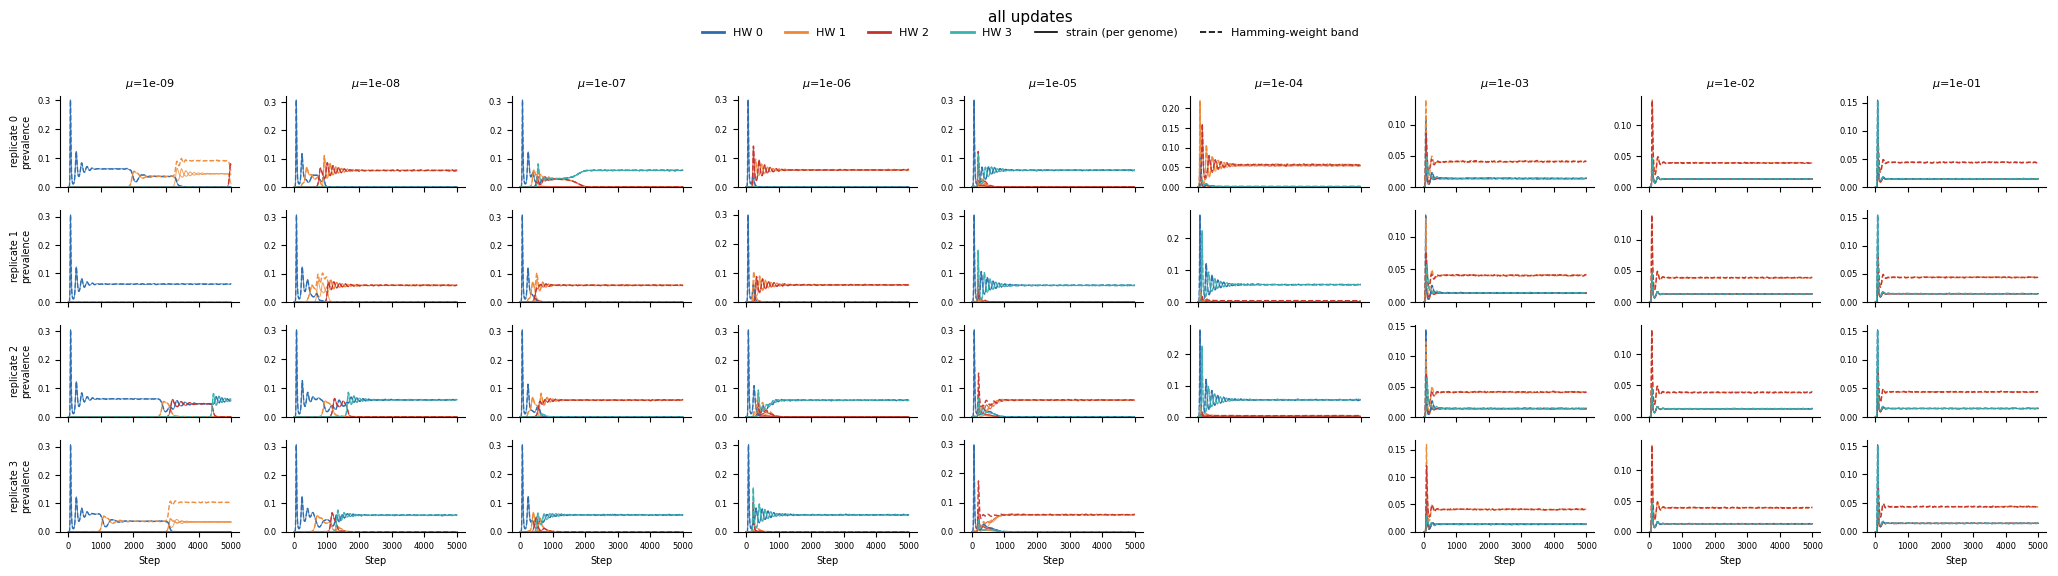

In [ ]:
make_trellis(hw_df, strain_hw_df, N_SITES, step_clip=None)

## Trellis --- First 2000 Updates

The same trellis clipped to the first **2000** updates (and dropping
the slowest `1e-9` rate) to zoom in on the establishment phase and
the start of the endemic plateau.

clip=2000 stride=2 grid=4 replicates x 8 rates
teeplots/2026-06-17-3site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=2000+viz=subplots+ext=.pdf
teeplots/2026-06-17-3site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=2000+viz=subplots+ext=.png


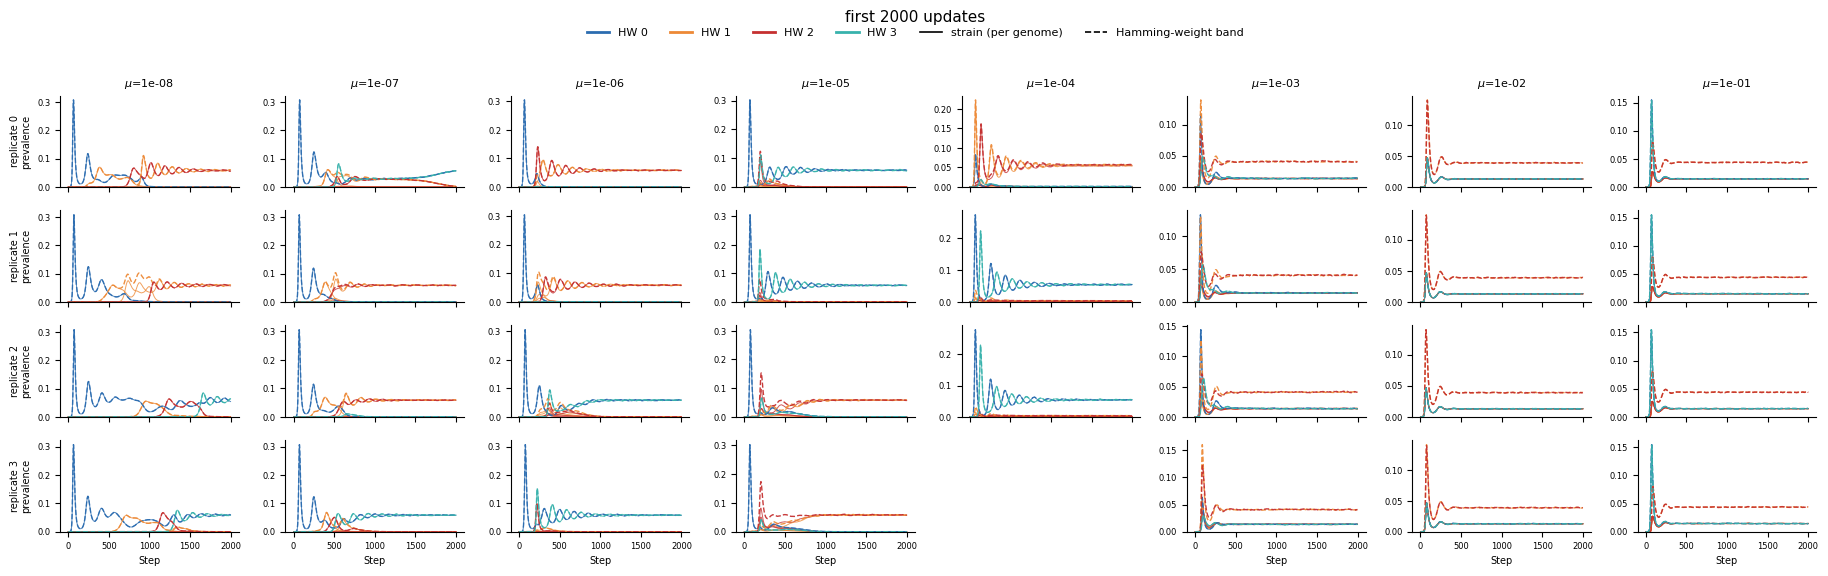

In [ ]:
make_trellis(
    hw_df, strain_hw_df, N_SITES, step_clip=2000, drop_slowest=True
)

## Trellis --- First 400 Updates

Clipped tighter, to the first **400** updates, to resolve the early
outbreak peak and the first strain-divergence transient before the
bands settle.

clip=400 stride=1 grid=4 replicates x 8 rates
teeplots/2026-06-17-3site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=400+viz=subplots+ext=.pdf
teeplots/2026-06-17-3site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=400+viz=subplots+ext=.png


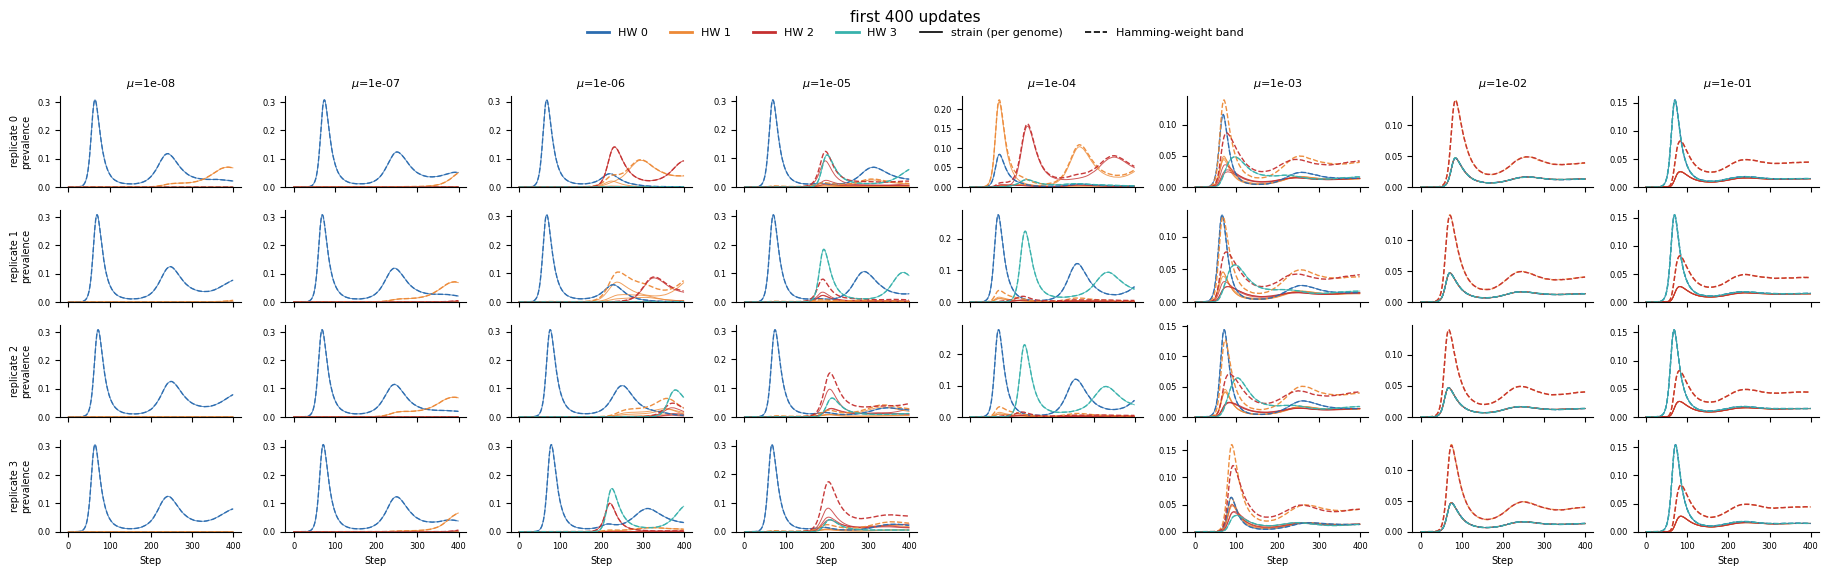

In [ ]:
make_trellis(
    hw_df, strain_hw_df, N_SITES, step_clip=400, drop_slowest=True
)

## Trellis --- First 200 Updates

The tightest zoom, to the first **200** updates, isolating the
initial founder-driven epidemic wave and the very first appearance
of mutant strains.

clip=200 stride=1 grid=4 replicates x 8 rates
teeplots/2026-06-17-3site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=200+viz=subplots+ext=.pdf
teeplots/2026-06-17-3site-strain-trajectories/a=strain-vs-hw-replicate-trellis+clip=200+viz=subplots+ext=.png


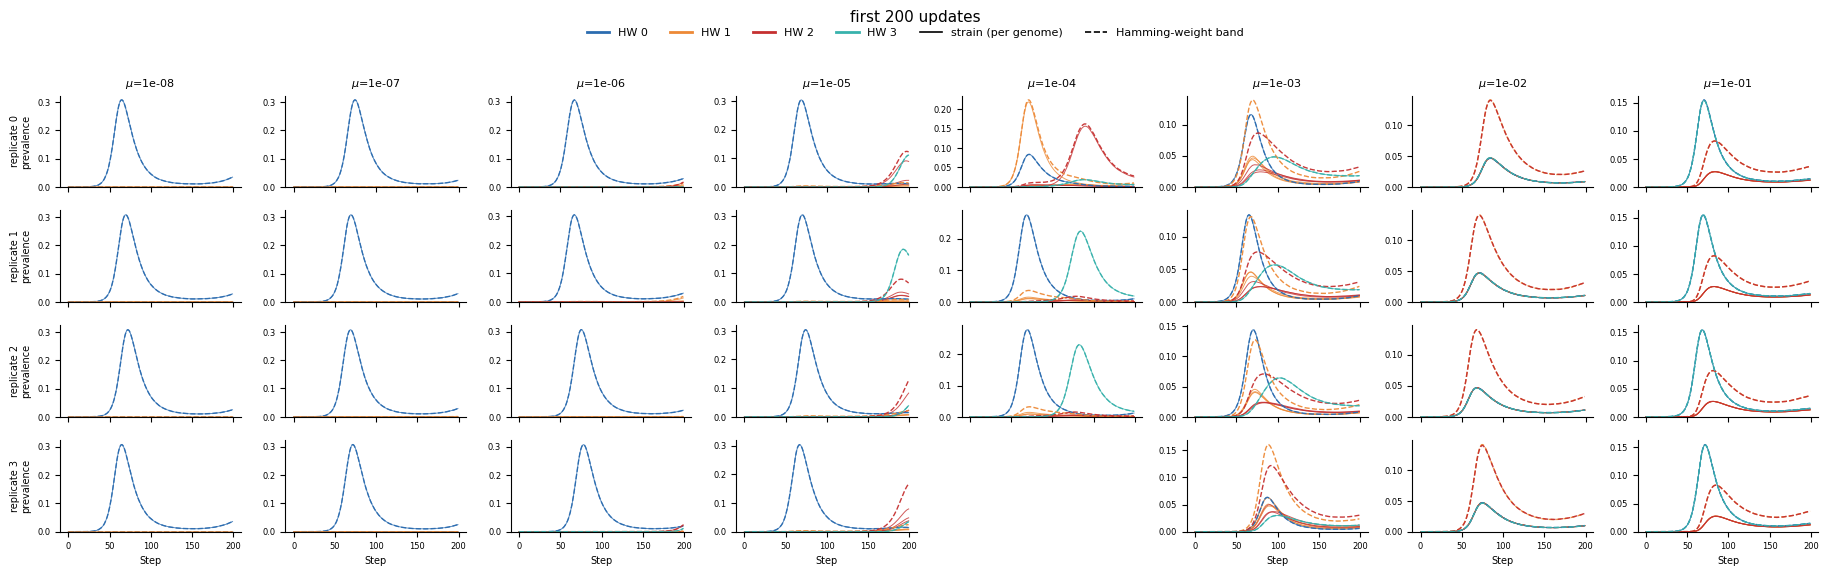

In [ ]:
make_trellis(
    hw_df, strain_hw_df, N_SITES, step_clip=200, drop_slowest=True
)

## End-State Dominant-Strain Complement Absence

Using the higher-replicate **`strain-final`** end-state snapshot
(`~200` replicates per rate), for each replicate identify the
**dominant strain** (the genome with the most cases). Its **bitwise
complement** is the genome with every allele flipped (`strain ^
(2**N_SITES - 1)`) --- e.g. the complement of the founder `000` is
`111`, and the complement of `010` is `101`. The complement always
shares the dominant strain's "opposite" Hamming weight `N_SITES - hw`.

We then plot, **per `mutation_rate`**, the **fraction of replicates
in which the complement is _absent_** (zero cases) at the final step.
A high fraction means end states tend to be one-sided (the dominant
strain's mirror image has died out / never established); a low
fraction means the complementary genome typically coexists. All 17
swept rates are shown on a log x-axis.

In [ ]:
_mask = (1 << N_SITES) - 1

# strain-final already holds one final-step snapshot per replicate.
_rows = []
for _rid, _sub in strain_final_df.groupby("replicate_uid"):
    _dom = int(_sub.loc[_sub["n_cases"].idxmax(), "strain"])
    _dom_hw = bin(_dom).count("1")
    _comp = _dom ^ _mask
    _comp_cases = int(
        _sub.loc[_sub["strain"] == _comp, "n_cases"].iloc[0],
    )
    _rows.append(
        {
            "replicate_uid": _rid,
            "mutation_rate": float(_sub["mutation_rate"].iloc[0]),
            "dominant_strain": _dom,
            "dominant_hw": _dom_hw,
            # Founder class == extreme Hamming weights {0, N_SITES};
            # intermediate == {1, 2}.
            "dominant_class": (
                "founder (HW 0/3)"
                if _dom_hw in (0, N_SITES)
                else "intermediate (HW 1/2)"
            ),
            "complement_strain": _comp,
            "complement_cases": _comp_cases,
            "complement_absent": _comp_cases == 0,
        },
    )
complement_df = pd.DataFrame(_rows)
print(f"complement frame: {complement_df.shape}")

complement frame: (3382, 8)


 mutation_rate  frac_absent  n_absent  n_total
  1.000000e-09     0.595000       119      200
  3.000000e-09     0.065327        13      199
  1.000000e-08     0.000000         0      194
  3.000000e-08     0.000000         0      200
  1.000000e-07     0.000000         0      196
  3.000000e-07     0.000000         0      200
  1.000000e-06     0.000000         0      200
  3.000000e-06     0.000000         0      195
  1.000000e-05     0.000000         0      200
  3.000000e-05     0.000000         0      200
  1.000000e-04     0.000000         0      200
  3.000000e-04     0.000000         0      200
  1.000000e-03     0.000000         0      200
  3.000000e-03     0.000000         0      200
  1.000000e-02     0.000000         0      198
  3.000000e-02     0.000000         0      200
  1.000000e-01     0.000000         0      200
teeplots/2026-06-17-3site-strain-trajectories/a=dominant-complement-absent-fraction+color=6a3d9a+marker=o+viz=lineplot+x=mutation-rate+y=frac-absent+ext=.

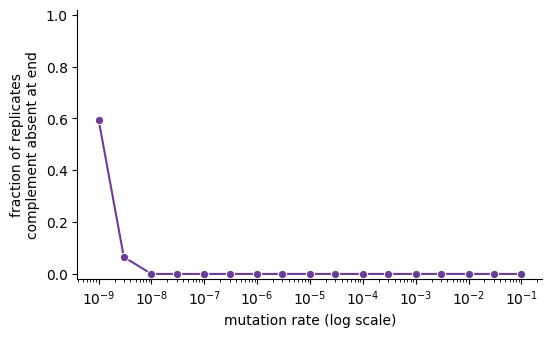

In [ ]:
_frac_df = (
    complement_df.groupby("mutation_rate")["complement_absent"]
    .agg(frac_absent="mean", n_absent="sum", n_total="count")
    .reset_index()
    .sort_values("mutation_rate")
)
print(_frac_df.to_string(index=False))

with tp.teed(
    sns.lineplot,
    data=_frac_df,
    x="mutation_rate",
    y="frac_absent",
    marker="o",
    color="#6a3d9a",
    teeplot_outattrs={"a": "dominant-complement-absent-fraction"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _ax:
    _ax.set_xscale("log")
    _ax.set_ylim(-0.02, 1.02)
    _ax.set_xlabel("mutation rate (log scale)")
    _ax.set_ylabel(
        "fraction of replicates\ncomplement absent at end",
    )
    sns.despine(ax=_ax)
    _ax.figure.set_size_inches(6, 3.5)

## Complement Absence Split by Dominant Hamming-Weight Class

The same end-state statistic, but with replicates **split by the
Hamming-weight class of the final dominant strain**: **founder**
(extreme weights `0`/`3` --- the founder `000` and its complement
`111`) versus **intermediate** (weights `1`/`2`). Each line is the
fraction of replicates *within that class* whose dominant-strain
complement is absent at the final step, per mutation rate. (Where a
class has no replicates at a given rate it simply has no point.)

 mutation_rate        dominant_class  frac_absent  n_absent  n_total
  1.000000e-09      founder (HW 0/3)     0.789474        60       76
  3.000000e-09      founder (HW 0/3)     0.055556         2       36
  1.000000e-08      founder (HW 0/3)     0.000000         0       23
  3.000000e-08      founder (HW 0/3)     0.000000         0       13
  1.000000e-07      founder (HW 0/3)     0.000000         0        4
  3.000000e-07      founder (HW 0/3)     0.000000         0        4
  1.000000e-06      founder (HW 0/3)     0.000000         0       12
  3.000000e-06      founder (HW 0/3)     0.000000         0       21
  1.000000e-05      founder (HW 0/3)     0.000000         0      162
  3.000000e-05      founder (HW 0/3)     0.000000         0      197
  1.000000e-04      founder (HW 0/3)     0.000000         0      198
  3.000000e-04      founder (HW 0/3)     0.000000         0      189
  1.000000e-03      founder (HW 0/3)     0.000000         0       39
  3.000000e-03      founder (HW 0/

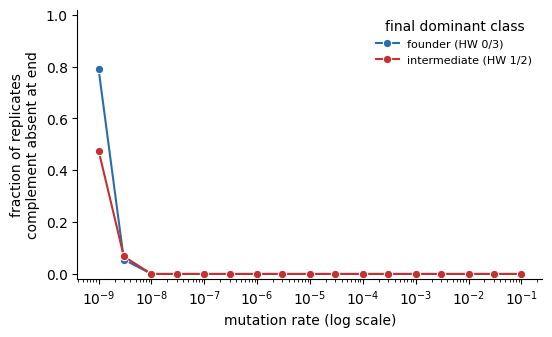

In [ ]:
_class_order = ["founder (HW 0/3)", "intermediate (HW 1/2)"]
_palette = {
    "founder (HW 0/3)": "#2b6cb0",
    "intermediate (HW 1/2)": "#c53030",
}
_frac_df = (
    complement_df.groupby(["mutation_rate", "dominant_class"])[
        "complement_absent"
    ]
    .agg(frac_absent="mean", n_absent="sum", n_total="count")
    .reset_index()
    .sort_values(["dominant_class", "mutation_rate"])
)
print(_frac_df.to_string(index=False))

with tp.teed(
    sns.lineplot,
    data=_frac_df,
    x="mutation_rate",
    y="frac_absent",
    hue="dominant_class",
    hue_order=_class_order,
    palette=_palette,
    marker="o",
    teeplot_outattrs={
        "a": "dominant-complement-absent-fraction-by-class",
    },
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _ax:
    _ax.set_xscale("log")
    _ax.set_ylim(-0.02, 1.02)
    _ax.set_xlabel("mutation rate (log scale)")
    _ax.set_ylabel(
        "fraction of replicates\ncomplement absent at end",
    )
    _ax.legend(title="final dominant class", frameon=False, fontsize=8)
    sns.despine(ax=_ax)
    _ax.figure.set_size_inches(6, 3.5)